# 我使用了什么库？

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
# 需要导入的库

import numpy as np
from sklearn.linear_model import LinearRegression

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data.dataset import random_split
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt




# 不再需要显示调用plt.show()
%matplotlib inline

# 设置plt的风格
plt.style.use('fivethirtyeight')

# 然后，我要干什么？

训练循环部分的代码现在和模型,优化器,损失函数是绑定在一起的，期望可以把这个过程抽象出来。


结合代码:

**Q**: 目前训练循环的逻辑和模型,优化器,损失函数是否是耦合的？



In [3]:
%run -i tmp_script/v0_data_gen.py
%run -i tmp_script/v0_data_pre.py
%run -i tmp_script/v0_model_config.py

In [4]:
# %load tmp_script/v0_model_training.py

n_epochs = 1000

for epoch in range(n_epochs):
    model.train()

    yhat = model(x_train_tensor)

    loss = loss_fn(yhat,y_train_tensor)

    loss.backward()

    optim_sgd.step()
    optim_sgd.zero_grad()


# 高阶函数

训练循环部分的代码现在和模型,优化器,损失函数是绑定在一起的，期望可以把这个过程抽象出来。

可以利用什么python函数式编程的**高阶函数**来实现这一点

结合代码:

**Q**: 如何使用高阶函数？

**Q**: loss在计算完后的位置在哪？在返回前保证什么？


In [5]:
# 程序3-1 高阶函数实现训练循环

# 返回的函数是训练循环内的内容
def make_train_step(model,loss_fn,optim_sgd):
    def train_step(x,y):
        model.train()

        yhat = model(x)

        loss = loss_fn(yhat,y)

        loss.backward()

        optim_sgd.step()

        optim_sgd.zero_grad()

        # 注意这里返回的loss要传回cpu!
        return loss.item()
    return train_step


# 里程碑

改造内容: 将使用高阶函数改造模型配置和模型训练部分

In [6]:
# 程序3-2 使用高阶函数来实现模型配置
%run -i tmp_script/v0_data_pre.py

In [7]:
%%writefile tmp_script/v1_model_config.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 0.1

torch.manual_seed(42)

model = nn.Sequential(nn.Linear(1, 1)).to(device)

optim_sgd = optim.SGD(model.parameters(), lr=lr)

loss_fn = nn.MSELoss(reduction='mean')

# 创建训练循环实例
train_step = make_train_step(model,loss_fn,optim_sgd)

Overwriting tmp_script/v1_model_config.py


In [8]:
# 运行并检查结果
%run -i tmp_script/v1_model_config.py
train_step

<function __main__.make_train_step.<locals>.train_step(x, y)>

In [9]:
# 程序3-3 使用高阶函数来实现模型配置和训练循环

In [10]:
%%writefile tmp_script/v1_model_training.py

n_epochs = 1000

# 使用列表存储loss的变化
losses = []

for epoch in range(n_epochs):
    loss = train_step(x_train_tensor,y_train_tensor)
    losses.append(loss)

Overwriting tmp_script/v1_model_training.py


In [11]:
# 运行并检查结果
%run -i tmp_script/v1_model_training.py

print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]])), ('0.bias', tensor([1.0235]))])


# 然后，我要干什么？

现在对于训练循环的封装基本告一段落，但是还有一处没有处理:
- 对于数据准备仍然使用比较松散的代码结构，且*不能支持所有梯度下降的种类*

另外，到目前位置，注意力一直放在**训练循环**和**参数**变化上，但是除了训练还有使用时的**评估模式**，以及它们运行的结果，即**损失**的变化，要将这些东西可视化才行


# 数据集: DataSet

**Q**: 对于简单张量,使用什么类进行处理？

结合代码:

**Q**: 数据集在Pytorch中如何表示？结构是什么？类是什么？

**Q**: 实现数据集要实现哪些方法？参数和返回值都是什么？

**Q**: 在初始化方法中加载整个数据集是否必要？

**Q**: 如何创建和使用张量数据集？

**Q**: 是否需要将数据一口气上传到GPU上？

In [12]:
# 程序 3-4: 创建自定义数据集
class CustomDataset(Dataset):
    def __init__(self,x_tensor,y_tensor):
        self.x = x_tensor
        self.y = y_tensor
    def __getitem__(self, index):
        return self.x[index],self.y[index]
    def __len__(self):
        return len(self.x)

In [13]:
#程序3-5: 使用自定义数据集

# 等同于 as_tensor
x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).float()

train_data = CustomDataset(x_train_tensor,y_train_tensor)
print(train_data[0])

(tensor([0.7713]), tensor([2.4745]))


In [14]:
# 程序3-6: TensorDataset的创建和使用

train_data = TensorDataset(x_train_tensor,y_train_tensor)
print(train_data[0], len(train_data))

(tensor([0.7713]), tensor([2.4745])) 80


# 数据加载:DataLoader

**Q**: 回顾梯度下降的种类,到目前为止，训练循环一直使用的是哪种梯度下降的方式?

**Q**: DataLoader解决了什么问题？还有哪些问题是暂时没涉及的？

**Q**: python知识: 迭代器和列表的区别？

**Q**: 回顾讨论训练数据和验证数据关于shuffle的必要性

结合代码:

**Q**: 小批量大小如何选择？一般数值是多少？


In [15]:
# 程序3-7: 数据加载器的使用

# 注意: 训练数据除了时序情况是要shuffle的
train_loader = DataLoader(dataset=train_data,batch_size=16,shuffle=True)
print(len(list(train_loader)))
print(next(iter(train_loader)))

5
[tensor([[0.7852],
        [0.8022],
        [0.6075],
        [0.1997],
        [0.3309],
        [0.6376],
        [0.4722],
        [0.2809],
        [0.4938],
        [0.5427],
        [0.1560],
        [0.1987],
        [0.3745],
        [0.0885],
        [0.7320],
        [0.8872]]), tensor([[2.5283],
        [2.6229],
        [2.4037],
        [1.3651],
        [1.5427],
        [2.1930],
        [1.9857],
        [1.5846],
        [1.9060],
        [2.2161],
        [1.2901],
        [1.2654],
        [1.7578],
        [1.0708],
        [2.4732],
        [2.8708]])]


# 里程碑

内容: 将使用数据加载器和数据集改造数据准备和模型训练的部分，并再次抽象新类型梯度下降的步骤

结合代码

**Q**: 模型训练部分较之前有什么变化？

**Q**: 对于内循环的损失计算如何处理？

**Q**: 讨论数据上传GPU的必要性

**Q**: 为什么运行时间变长了？(统计各自的训练次数)

In [16]:
# 程序3-8: 修改数据准备: 数据加载器,数据集

In [17]:
%%writefile tmp_script/v1_data_pre.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

x_train_tensor = torch.as_tensor(x_train).float()
y_train_tensor = torch.as_tensor(y_train).float()

train_data = TensorDataset(x_train_tensor,y_train_tensor)

train_loader = DataLoader(dataset=train_data,batch_size=16,shuffle=True)


Overwriting tmp_script/v1_data_pre.py


In [18]:
# 运行结果
%run -i tmp_script/v1_data_pre.py

In [19]:
# 模型配置保持不变
%run -i tmp_script/v1_model_config.py

In [20]:
# 程序3-9: 模型训练: 数据加载器,数据集

In [21]:
%%writefile tmp_script/v2_model_training.py

n_epochs = 1000

# 使用列表存储loss的变化
losses = []

for epoch in range(n_epochs):

    mini_batch_loss = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        tmp_loss = train_step(x_batch,y_batch)
        mini_batch_loss.append(tmp_loss)
    loss = np.mean(mini_batch_loss)

    losses.append(loss)

Overwriting tmp_script/v2_model_training.py


In [22]:
# 运行并结果
%run -i tmp_script/v2_model_training.py

print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9696]])), ('0.bias', tensor([1.0243]))])


In [23]:
#程序3-10: 抽象下批量训练循环

def mini_batch(device,data_loader,step_func):
    mini_batch_loss = []
    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        tmp_loss = step_func(x_batch,y_batch)
        mini_batch_loss.append(tmp_loss)
    loss = np.mean(mini_batch_loss)

    return loss

In [24]:
# 程序3-11 修改模型训练:小批量抽象

# 数据准备和模型配置不变
%run -i tmp_script/v1_data_pre.py
%run -i tmp_script/v1_model_config.py

In [25]:
%%writefile tmp_script/v3_model_training.py

# 保持训练次数一致
n_epochs = 200

# 使用列表存储loss的变化
losses = []

for epoch in range(n_epochs):

    loss = mini_batch(device,train_loader,train_step)

    losses.append(loss)

Overwriting tmp_script/v3_model_training.py


In [26]:
# 运行并验证结果
%run -i tmp_script/v3_model_training.py

print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9684]])), ('0.bias', tensor([1.0219]))])


# 数据拆分

另外，到目前位置，注意力一直放在**训练循环**和**参数**变化上，但是除了训练还有使用时的**评估模式**

首先需要为其准备数据，目前对于训练数据的处理方式是:
- data_gen 负责生成和拆分
- data_pre 负责封装DataSet和DataLoader

其实，一旦引入DataSet,拆分的工作可以从索引切片交给pytorch函数处理，好处是不用繁琐的手动建立DataSet

结合代码:

**Q**: 如何实现DataSet的生成和拆分？


## 里程碑

内容: 合并和修改数据生成和数据准备的步骤: DataSet拆分

In [27]:
# 程序3-12: 数据生成和数据准备:DataSet拆分

In [28]:
%%writefile tmp_script/v2_data_pre.py

# 数据生成

np.random.seed(42)

true_b = 1
true_w = 2
N = 100

x = np.random.rand(N, 1)
y = true_b + true_w * x + (.1 * np.random.randn(N, 1))

# Shuffles the indices
#idx = np.arange(N)
#np.random.shuffle(idx)

# Uses first 80 random indices for train
#train_idx = idx[:int(N*.8)]
# Uses the remaining indices for validation
#val_idx = idx[int(N*.8):]

# Generates train and validation sets
#x_train, y_train = x[train_idx], y[train_idx]
#x_val, y_val = x[val_idx], y[val_idx]


# 数据准备

#device = 'cuda' if torch.cuda.is_available() else 'cpu'

#x_train_tensor = torch.as_tensor(x_train).float()
#y_train_tensor = torch.as_tensor(y_train).float()

#train_data = TensorDataset(x_train_tensor,y_train_tensor)

#train_loader = DataLoader(dataset=train_data,batch_size=16,shuffle=True)

torch.manual_seed(13)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

x_all_tensor = torch.as_tensor(x).float()
y_all_tensor = torch.as_tensor(y).float()

dataset = TensorDataset(x_all_tensor,y_all_tensor)

## 执行拆分

ratio = .8
n_total = len(dataset)
n_train = int(ratio * n_total)
n_val = n_total - n_train

train_data,val_data = random_split(dataset,[n_train,n_val])

train_loader = DataLoader(dataset=train_data,batch_size=16,shuffle=True)

# 注意: 验证数据无须shuffle
val_loader = DataLoader(dataset=val_data,batch_size=16)


Overwriting tmp_script/v2_data_pre.py


In [29]:
# 运行
%run -i tmp_script/v2_data_pre.py
%run -i tmp_script/v1_model_config.py
%run -i tmp_script/v3_model_training.py

print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9453]])), ('0.bias', tensor([1.0307]))])


# 评估

**Q**: 评估和训练模式在实现上有什么不同？有什么重要设置？

结合代码:

**Q**: 如何实现评估模式？

In [30]:
# 程序3-13: 评估模式循环抽象

def make_val_step_fn(model,loss_fn):
    def val_step(x,y):
        #注意: 要设置评估模式
        model.eval()
        # 前向传播
        yhat = model(x)
        # 计算损失
        loss = loss_fn(yhat,y)
        # 不需要更新参数
        return loss.item()
    return val_step


## 里程碑

内容: 添加评估模式到模型配置和训练循环中

结合代码:

**Q**: 验证阶段如何处理梯度问题？

In [31]:
# 程序3-14: 添加评估模式到模型配置

In [32]:
%%writefile tmp_script/v2_model_config.py


device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 0.1

torch.manual_seed(42)

model = nn.Sequential(nn.Linear(1, 1)).to(device)

optim_sgd = optim.SGD(model.parameters(), lr=lr)

loss_fn = nn.MSELoss(reduction='mean')

# 创建训练循环实例
train_step = make_train_step(model,loss_fn,optim_sgd)
val_step = make_val_step_fn(model,loss_fn)

Overwriting tmp_script/v2_model_config.py


In [33]:
# 程序3-15: 添加评估模式到模型训练

In [34]:
%%writefile tmp_script/v4_model_training.py

# 保持训练次数一致
n_epochs = 200

# 使用列表存储loss的变化
losses = []
val_losses = []

for epoch in range(n_epochs):
    # 训练内循环
    loss = mini_batch(device,train_loader,train_step)
    losses.append(loss)
    # 验证部分
    # 注意: 验证不需要梯度更新
    with torch.no_grad():
        val_loss = mini_batch(device,val_loader,val_step)
        val_losses.append(val_loss)


Overwriting tmp_script/v4_model_training.py


In [35]:
# 运行和验证

%run -i tmp_script/v2_data_pre.py
%run -i tmp_script/v2_model_config.py
%run -i tmp_script/v4_model_training.py

print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9438]])), ('0.bias', tensor([1.0287]))])


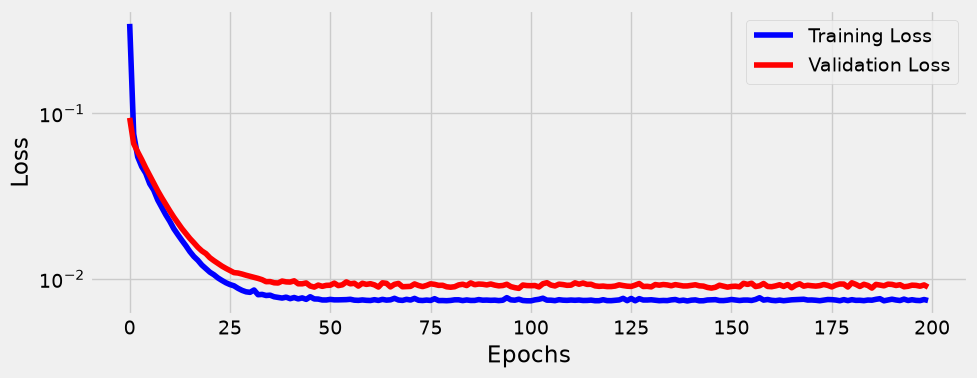

In [36]:
# 可视化结果
from plots.chapter2 import *
fig = plot_losses(losses, val_losses)

# 然后，我要干什么？

目前,评估模式和训练模式都已经就位，现在要把注意力放在损失的变化上，所以不在依赖自己画图，而是使用组件进行可视化

最后,需要考虑下模型的状态如何保存和读取，以便下发和复用


# TensorBoard

结合代码

**Q**: 如何加载和登录TensorBoard？


**Q**: 记录的路径如何指定？

In [37]:
#程序3-16 加载TensorBoard
%reload_ext tensorboard

%tensorboard --logdir logs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "D:\moreEnv\anaconda\envs\haienv\Scripts\tensorboard-script.py", line 5, in <module>
    from tensorboard.main import run_main
  File "D:\moreEnv\anaconda\envs\haienv\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "D:\moreEnv\anaconda\envs\haienv\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

## SummaryWriter

结合代码:

**Q**: 如何创建`SummaryWriter`

**Q**: 指定路径时的注意点有哪些？

**Q**: 如何添加graph和scalar？这两者对应哪些部分？

> graph可以理解为通过模型和输入展示计算图，可以用来检查模型的逻辑

> scalar则是一些标量变化的跟踪图

In [38]:
# 程序3-17: add_graph的使用
from datetime import datetime

writer = SummaryWriter("logs/test_"+datetime.now().timestamp().__str__())

dummy_x,dummy_y = next(iter(train_loader))
writer.add_graph(model,dummy_x.to(device))

In [39]:
# 程序3-18: add_scalars的使用

# 可以使用add_scalars方法一次性发送多个标量值
# 参数:组tag,键值对字典,全局步长
print(loss,val_loss,epoch)
writer.add_scalars(
    main_tag='loss',
    tag_scalar_dict = {'training': loss, 'validation': val_loss},
    global_step = epoch)

writer.close()

0.007432235311716795 0.008957521757110953 199


# 里程碑

内容: 给模型配置和训练循环加上tensorboard的跟踪可视化逻辑

In [40]:
# 程序3-19: 模型配置:添加SummaryWriter 和 模型graph

In [41]:
%%writefile tmp_script/v3_model_config.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 0.1

torch.manual_seed(42)

model = nn.Sequential(nn.Linear(1, 1)).to(device)

optim_sgd = optim.SGD(model.parameters(), lr=lr)

loss_fn = nn.MSELoss(reduction='mean')

# 创建训练循环实例
train_step = make_train_step(model,loss_fn,optim_sgd)
val_step = make_val_step_fn(model,loss_fn)

# 添加writer
writer = SummaryWriter("logs/simple_linear_"+datetime.now().timestamp().__str__())


x_sample,y_sample = next(iter(train_loader))
writer.add_graph(model,x_sample.to(device))

Overwriting tmp_script/v3_model_config.py


In [42]:
# 程序3-20: 模型训练:添加SummaryWriter和scalar

In [43]:
%%writefile tmp_script/v5_model_training.py


# 保持训练次数一致
n_epochs = 200

# 使用列表存储loss的变化
losses = []
val_losses = []

for epoch in range(n_epochs):
    # 训练内循环
    loss = mini_batch(device,train_loader,train_step)
    losses.append(loss)
    # 验证部分
    # 注意: 验证不需要梯度更新
    with torch.no_grad():
        val_loss = mini_batch(device,val_loader,val_step)
        val_losses.append(val_loss)
    writer.add_scalars(
        main_tag='loss',
        tag_scalar_dict = {'training': loss, 'validation': val_loss},
        global_step = epoch)

writer.close()

Overwriting tmp_script/v5_model_training.py


In [44]:
# 运行并验证


%run -i tmp_script/v2_data_pre.py
%run -i tmp_script/v3_model_config.py
%run -i tmp_script/v5_model_training.py

<Figure size 640x480 with 0 Axes>

# 保存和加载模型

**Q**: 对模型来说,要保存什么状态？

结合代码:

**Q**: 如何保存模型？

**Q**: 如何恢复状态？`weights_only`参数的意义是什么？

**Q**: 如何"部署"模型？

In [45]:
# 程序3-21: 保存模型

checkpoint = {'epoch': n_epochs,
              'model_state_dict': model.state_dict(),
              'optim_state_dict': optim_sgd.state_dict(),
              'loss':losses,
              'val_loss':val_losses }

torch.save(checkpoint,'model_checkpoint.pth')

In [46]:
# 程序3-22: 恢复训练

# 初始化模型
%run -i tmp_script/v2_data_pre.py
%run -i tmp_script/v3_model_config.py

print(model.state_dict())

# 注意: weights_only 指示反序列化器是否应仅限于加载张量、原始类型、字典以及通过 torch.serialization.add_safe_globals 添加的任何类型
checkpoint = torch.load('model_checkpoint.pth',weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
optim_sgd.load_state_dict(checkpoint['optim_state_dict'])

saved_epoch = checkpoint['epoch']
saved_losses = checkpoint['loss']
saved_val_losses = checkpoint['val_loss']

# 注意恢复模型的执行模式
model.train()

print(model.state_dict())


OrderedDict([('0.weight', tensor([[0.7645]])), ('0.bias', tensor([0.8300]))])
OrderedDict([('0.weight', tensor([[1.9432]])), ('0.bias', tensor([1.0263]))])


OrderedDict([('0.weight', tensor([[1.9432]])), ('0.bias', tensor([1.0263]))])


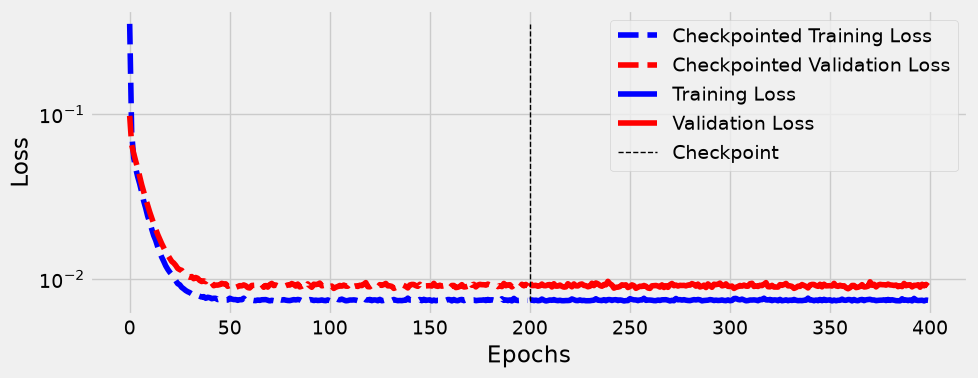

In [47]:
# 程序3-23: 检验恢复训练后的连续情况

# 接续训练后的状态继续训练
%run -i tmp_script/v5_model_training.py

print(model.state_dict())

fig = plot_resumed_losses(saved_epoch, saved_losses, saved_val_losses, n_epochs, losses, val_losses)

## 部署模型

结合代码:

**Q**: 如何部署一个模型

In [48]:
# 程序3-24: 部署模型

# 初始化模型
%run -i tmp_script/v3_model_config.py

# 加载状态

checkpoint = torch.load('model_checkpoint.pth',weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

print(model.state_dict())

# 预测新的输入

new_inputs = torch.tensor([[.20],[.34],[.57]])

## 注意预测模式
model.eval()

model(new_inputs.to(device))


OrderedDict([('0.weight', tensor([[1.9432]])), ('0.bias', tensor([1.0263]))])


tensor([[1.4150],
        [1.6870],
        [2.1340]], grad_fn=<AddmmBackward0>)

<Figure size 640x480 with 0 Axes>

# 总结

In [49]:
# 运行并验证


%run -i tmp_script/v2_data_pre.py
%run -i tmp_script/v3_model_config.py
%run -i tmp_script/v5_model_training.py

print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9432]])), ('0.bias', tensor([1.0263]))])
